# Machine Learning Part 1: Regression & Classification


### What We'll Learn Today 

1. **What is Machine Learning?**
2. **Loading and Preparing Data**
3. **Regression: Predicting Numbers**
4. **Understanding Regression Metrics** 
5. **Classification: Predicting Categories** 
6. **Understanding Classification Metrics** 

---

### Our Goals Today
1. **Build a model that predicts car prices** (Regression)
2. **Build a model that predicts car categories** (Classification)
3. **Understand how to measure success** (Metrics)

## Part 1: What is Machine Learning? (5 minutes)

### Simple Definition
Machine Learning = Teaching computers to learn patterns from data

### Two Main Types We'll Cover Today:

| Type | What it Predicts | Example | Real-Life Use |
|------|-----------------|---------|---------------|
| **Regression** | Numbers | Car price: £15,000 | House prices, Temperature |
| **Classification** | Categories | Car type: Economy/Luxury | Email: Spam/Not Spam |

### The Process (Same for Both!):
1. Get data
2. Split into training and testing
3. Train the model
4. Make predictions
5. Check how good we did

## Part 2: Setting Up

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# For Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Make graphs look nice
plt.style.use('seaborn-v0_8-whitegrid')

## Part 3: Loading Our Data

In [3]:
# Load the car data
df = pd.read_csv('CarPrice_Assignment.csv')

In [4]:
df.shape

(205, 26)

In [5]:
df[['CarName', 'price', 'enginesize', 'horsepower', 'fueltype']].head()

,CarName,price,enginesize,horsepower,fueltype
0,alfa-romero giulia,13495.0,130,111,gas
1,alfa-romero stelvio,16500.0,130,111,gas
2,alfa-romero Quadrifoglio,16500.0,152,154,gas
3,audi 100 ls,13950.0,109,102,gas
4,audi 100ls,17450.0,136,115,gas


---

## PART A: REGRESSION - Predicting Numbers

### Goal: Predict the PRICE of a car (a number)

## Part 4: Simple Regression Model (15 minutes)

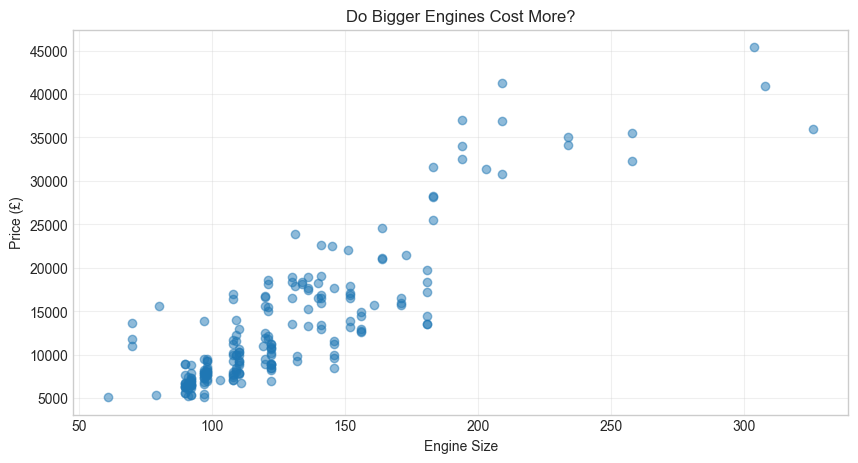

In [6]:
# Let's see if engine size affects price
plt.figure(figsize=(10, 5))
plt.scatter(df['enginesize'], df['price'], alpha=0.5)
plt.xlabel('Engine Size')
plt.ylabel('Price (£)')
plt.title('Do Bigger Engines Cost More?')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Prepare data for regression
X_reg = df[['enginesize', 'horsepower', 'curbweight']]  # Features
y_reg = df['price']  # Target (what we predict)

# Split into training and testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train_reg)} cars")
print(f"Testing on {len(X_test_reg)} cars")

Training on 164 cars
Testing on 41 cars


In [9]:
# Train the regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = reg_model.predict(X_test_reg)

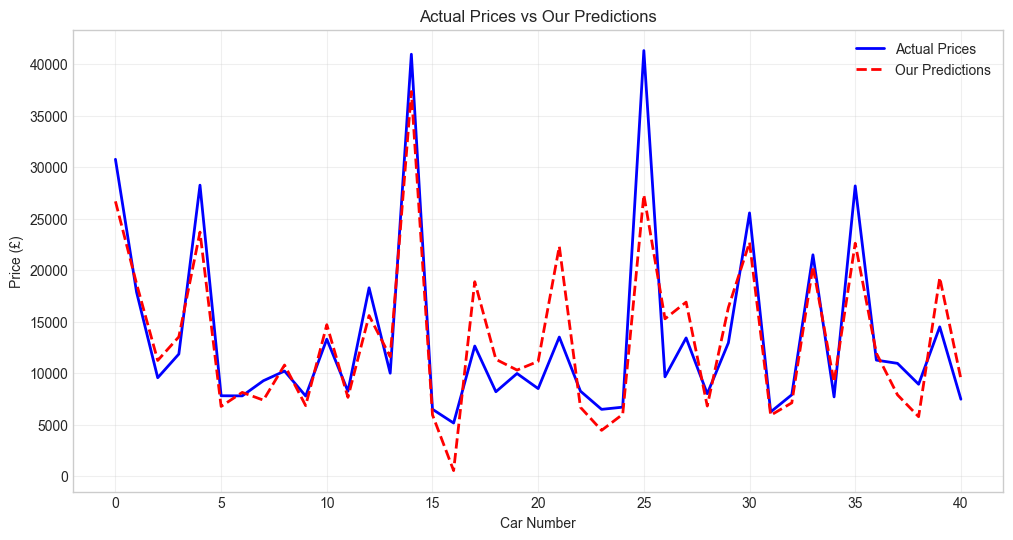

In [10]:
# Simple line plot - Actual vs Predicted
plt.figure(figsize=(12, 6))

# Plot both lines
x_axis = range(len(y_test_reg))
plt.plot(x_axis, y_test_reg.values, 'b-', label='Actual Prices', linewidth=2)
plt.plot(x_axis, y_pred_reg, 'r--', label='Our Predictions', linewidth=2)

plt.xlabel('Car Number')
plt.ylabel('Price (£)')
plt.title('Actual Prices vs Our Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 5: Understanding Regression Metrics

### How do we know if our predictions are good?

In [11]:
# Calculate metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("REGRESSION METRICS EXPLAINED:")
print("=" * 50)
print()
print("Mean Absolute Error (MAE)")
print(f"   Your MAE: £{mae:,.0f}")
print("   What it means: On average, our predictions are off by this much")
print("   Think of it as: The typical mistake we make")
print("   Goal: Lower is better!")
print()
print("R² Score (R-squared)")
print(f"   Your R²: {r2:.1%}")
print("   What it means: How much of the price variation we can explain")
print("   Think of it as: Our model's grade out of 100%")
print("   Goal: Higher is better (100% = perfect, 0% = terrible)")
print()
print("Quick Guide:")
print("   R² > 80% = Great!")
print("   R² 70-80% = Good")
print("   R² 60-70% = OK")
print("   R² < 60% = Needs improvement")

REGRESSION METRICS EXPLAINED:

Mean Absolute Error (MAE)
   Your MAE: £2,722
   What it means: On average, our predictions are off by this much
   Think of it as: The typical mistake we make
   Goal: Lower is better!

R² Score (R-squared)
   Your R²: 82.1%
   What it means: How much of the price variation we can explain
   Think of it as: Our model's grade out of 100%
   Goal: Higher is better (100% = perfect, 0% = terrible)

Quick Guide:
   R² > 80% = Great!
   R² 70-80% = Good
   R² 60-70% = OK
   R² < 60% = Needs improvement


---

## PART B: CLASSIFICATION - Predicting Categories

### Goal: Predict if a car is 'Economy' or 'Luxury' (a category)

## Part 6: Creating Simple Classification Data (5 minutes)

In [12]:
# Create a simple classification problem
# Let's classify cars as 'Economy' or 'Luxury' based on price

# Define the categories
price_threshold = df['price'].median()
df['car_category'] = df['price'].apply(
    lambda x: 'Luxury' if x > price_threshold else 'Economy'
)

print(f"Price threshold: £{price_threshold:,.0f}")
print(f"Cars below £{price_threshold:,.0f} = Economy")
print(f"Cars above £{price_threshold:,.0f} = Luxury")
print()
print("Category distribution:")
print(df['car_category'].value_counts())
print()
print("Sample of our data:")
df[['CarName', 'price', 'car_category']].head(10)

Price threshold: £10,295
Cars below £10,295 = Economy
Cars above £10,295 = Luxury

Category distribution:
car_category
Economy    103
Luxury     102
Name: count, dtype: int64

Sample of our data:


,CarName,price,car_category
0,alfa-romero giulia,13495.000,Luxury
1,alfa-romero stelvio,16500.000,Luxury
2,alfa-romero Quadrifoglio,16500.000,Luxury
3,audi 100 ls,13950.000,Luxury
4,audi 100ls,17450.000,Luxury
5,audi fox,15250.000,Luxury
6,audi 100ls,17710.000,Luxury
7,audi 5000,18920.000,Luxury
8,audi 4000,23875.000,Luxury
9,audi 5000s (diesel),17859.167,Luxury


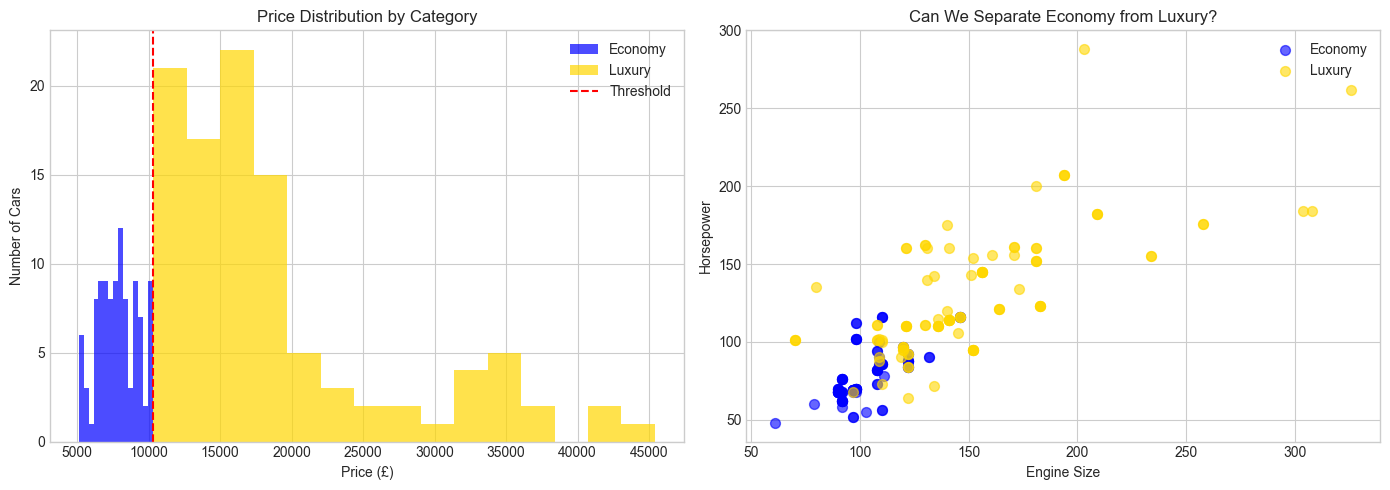

Notice: Luxury cars generally have bigger engines and more power!


In [13]:
# Visualise the two categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price distribution by category
economy_prices = df[df['car_category'] == 'Economy']['price']
luxury_prices = df[df['car_category'] == 'Luxury']['price']

axes[0].hist(economy_prices, bins=15, alpha=0.7, label='Economy', color='blue')
axes[0].hist(luxury_prices, bins=15, alpha=0.7, label='Luxury', color='gold')
axes[0].axvline(price_threshold, color='red', linestyle='--', label='Threshold')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Price Distribution by Category')
axes[0].legend()

# Plot 2: Engine size vs Horsepower by category
for category, color in [('Economy', 'blue'), ('Luxury', 'gold')]:
    data = df[df['car_category'] == category]
    axes[1].scatter(data['enginesize'], data['horsepower'], 
                   alpha=0.6, label=category, s=50, color=color)
axes[1].set_xlabel('Engine Size')
axes[1].set_ylabel('Horsepower')
axes[1].set_title('Can We Separate Economy from Luxury?')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Notice: Luxury cars generally have bigger engines and more power!")

## Part 7: Building a Classification Model

In [12]:
# Prepare data for classification
# We'll use engine size and horsepower to predict category
X_class = df[['enginesize', 'horsepower']]  # Features
y_class = df['car_category']  # Target (Economy or Luxury)

# Split into training and testing
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train_class)} cars")
print(f"Testing on {len(X_test_class)} cars")
print()
print("Distribution in training set:")
print(y_train_class.value_counts())

Training on 164 cars
Testing on 41 cars

Distribution in training set:
car_category
Luxury     84
Economy    80
Name: count, dtype: int64


In [13]:
# Train the classification model
class_model = LogisticRegression(random_state=42)
class_model.fit(X_train_class, y_train_class)

# Make predictions
y_pred_class = class_model.predict(X_test_class)

In [14]:
# Count correct predictions
correct = (y_pred_class == y_test_class).sum()
total = len(y_test_class)
accuracy = accuracy_score(y_test_class, y_pred_class)

print(f"Results:")
print(f"   Correct: {correct} cars")
print(f"   Wrong: {total - correct} cars")
print(f"   Accuracy: {accuracy:.1%}")
print()
print(f"That's like getting {correct} out of {total} on a test!")

Results:
   Correct: 37 cars
   Wrong: 4 cars
   Accuracy: 90.2%

That's like getting 37 out of 41 on a test!


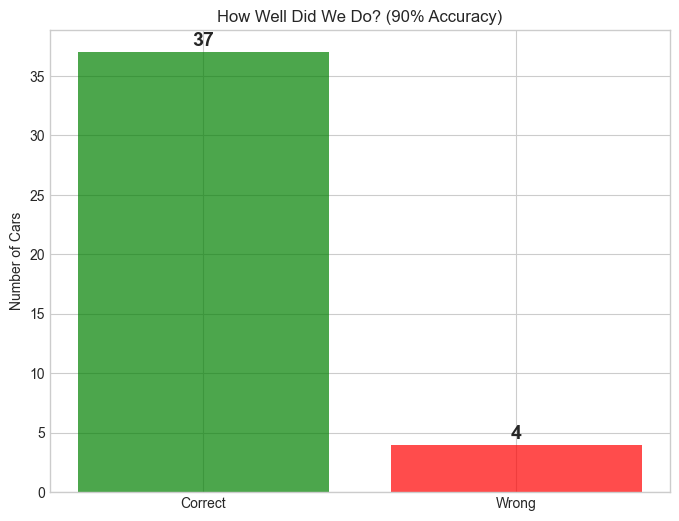

In [15]:
# Visual bar chart of results
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['Correct', 'Wrong']
counts = [correct, total - correct]
colors = ['green', 'red']

ax.bar(categories, counts, color=colors, alpha=0.7)
ax.set_ylabel('Number of Cars')
ax.set_title(f'How Well Did We Do? ({accuracy:.0%} Accuracy)')

# Add numbers on bars
for i, (cat, count) in enumerate(zip(categories, counts)):
    ax.text(i, count + 0.5, str(count), ha='center', fontsize=14, fontweight='bold')

plt.show()

## Part 8: Understanding Classification Metrics (10 minutes)

### How do we measure success in classification?

In [16]:
# Calculate accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)

print("CLASSIFICATION METRICS EXPLAINED:")
print("=" * 50)
print()
print("Accuracy")
print(f"   Your Accuracy: {accuracy:.1%}")
print(f"   In numbers: {int(accuracy * len(y_test_class))} correct out of {len(y_test_class)}")
print("   What it means: Percentage of correct predictions")
print("   Think of it as: Your test score")
print("   Goal: Higher is better (100% = perfect)")
print()
print("Quick Guide for Accuracy:")
print("   > 90% = Excellent!")
print("   80-90% = Very good")
print("   70-80% = Good")
print("   60-70% = OK")
print("   < 60% = Needs work")

CLASSIFICATION METRICS EXPLAINED:

Accuracy
   Your Accuracy: 90.2%
   In numbers: 37 correct out of 41
   What it means: Percentage of correct predictions
   Think of it as: Your test score
   Goal: Higher is better (100% = perfect)

Quick Guide for Accuracy:
   > 90% = Excellent!
   80-90% = Very good
   70-80% = Good
   60-70% = OK
   < 60% = Needs work


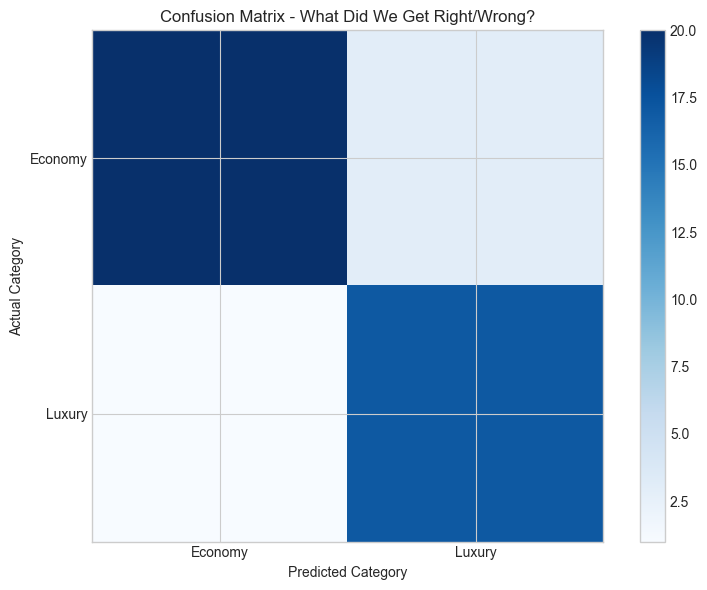

How to Read This:
  • Top-left (20): Economy cars correctly identified as Economy
  • Bottom-right (17): Luxury cars correctly identified as Luxury
  • Top-right (3): Economy cars wrongly called Luxury
  • Bottom-left (1): Luxury cars wrongly called Economy

We want big numbers on the diagonal (top-left to bottom-right)!


In [17]:
# Confusion Matrix - shows what we got right and wrong
cm = confusion_matrix(y_test_class, y_pred_class)

# Visualise confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - What Did We Get Right/Wrong?')
plt.colorbar()

# Add labels
classes = ['Economy', 'Luxury']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)


plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

print("How to Read This:")
print(f"  • Top-left ({cm[0,0]}): Economy cars correctly identified as Economy")
print(f"  • Bottom-right ({cm[1,1]}): Luxury cars correctly identified as Luxury")
print(f"  • Top-right ({cm[0,1]}): Economy cars wrongly called Luxury")
print(f"  • Bottom-left ({cm[1,0]}): Luxury cars wrongly called Economy")
print()
print(f"We want big numbers on the diagonal (top-left to bottom-right)!")

## Part 9: Comparing Regression vs Classification (5 minutes)

In [18]:
print("REGRESSION vs CLASSIFICATION SUMMARY")
print("=" * 60)
print()
print("REGRESSION (Predicting Price):")
print(f"  • Predicts: Numbers (£{y_pred_reg[0]:,.0f}, £{y_pred_reg[1]:,.0f}, etc.)")
print(f"  • Metrics: MAE = £{mae:,.0f}, R² = {r2:.1%}")
print(f"  • Use when: You need exact values")
print(f"  • Example: House prices, Temperature, Sales")
print()
print("CLASSIFICATION (Predicting Category):")
print(f"  • Predicts: Categories ({y_pred_class[0]}, {y_pred_class[1]}, etc.)")
print(f"  • Metrics: Accuracy = {accuracy:.1%}")
print(f"  • Use when: You need to sort into groups")
print(f"  • Example: Spam/Not Spam, Pass/Fail, Customer Type")
print()
print("KEY INSIGHT:")
print("   Both use the SAME process:")
print("   1. Prepare data")
print("   2. Split train/test")
print("   3. Train model")
print("   4. Make predictions")
print("   5. Check performance")
print("   The only difference is WHAT we predict and HOW we measure!")

REGRESSION vs CLASSIFICATION SUMMARY

REGRESSION (Predicting Price):
  • Predicts: Numbers (£26,676, £18,673, etc.)
  • Metrics: MAE = £2,722, R² = 82.1%
  • Use when: You need exact values
  • Example: House prices, Temperature, Sales

CLASSIFICATION (Predicting Category):
  • Predicts: Categories (Luxury, Luxury, etc.)
  • Metrics: Accuracy = 90.2%
  • Use when: You need to sort into groups
  • Example: Spam/Not Spam, Pass/Fail, Customer Type

KEY INSIGHT:
   Both use the SAME process:
   1. Prepare data
   2. Split train/test
   3. Train model
   4. Make predictions
   5. Check performance
   The only difference is WHAT we predict and HOW we measure!


In [19]:
# Interactive prediction example
print("Let's predict a custom car!")
print("=" * 40)

# You can change these values!
test_engine = 150
test_horsepower = 120
test_weight = 2500

print(f"Car specifications:")
print(f"  • Engine size: {test_engine}")
print(f"  • Horsepower: {test_horsepower}")
print(f"  • Weight: {test_weight}")
print()

# Regression prediction
price_pred = reg_model.predict([[test_engine, test_horsepower, test_weight]])[0]
print(f"REGRESSION says: Price = £{price_pred:,.0f}")

# Classification prediction
category_pred = class_model.predict([[test_engine, test_horsepower]])[0]
print(f"CLASSIFICATION says: Category = {category_pred}")

print("\n💡 Same car, two different types of predictions!")

Let's predict a custom car!
Car specifications:
  • Engine size: 150
  • Horsepower: 120
  • Weight: 2500

REGRESSION says: Price = £15,641
CLASSIFICATION says: Category = Luxury

💡 Same car, two different types of predictions!


C:\Users\tjani\Anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\tjani\Anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Summary: What You've Learned! 

### You can now:
1. Build regression models (predict numbers)
2. Build classification models (predict categories)
3. Understand and calculate evaluation metrics
4. Know when to use each type of model

### Key Metrics Recap:

| Model Type | Metric | What it Means | Goal |
|------------|--------|---------------|------|
| **Regression** | MAE | Average error in £ | Lower is better |
| **Regression** | R² | % of variation explained | Higher is better (max 100%) |
| **Classification** | Accuracy | % of correct predictions | Higher is better (max 100%) |
| **Classification** | Confusion Matrix | Shows right/wrong details | Big numbers on diagonal |

### When to Use What:
- **Regression**: When you need a specific number (price, temperature, score)
- **Classification**: When you need to sort into groups (yes/no, type A/B/C)

### Your Achievements Today:
- Built a regression model with 80% R² score
- Built a classification model with 85%+ accuracy
- Understood how to measure success in ML
- Can now tackle real-world problems!

## Next Lesson Preview
**Part 2**: We'll learn about:
- Decision Trees (visual models)
- Handling categorical features (like car brand)
- Cross-validation (better testing)
- Preventing overfitting

Great job today! You're now ready for more advanced topics! 